# 1. INSTALL DEPENDENCIES

In [15]:
# We install arabic-reshaper and python-bidi to fix Persian text in plots
!pip install -q kagglehub pandas matplotlib seaborn pyarrow fastparquet arabic-reshaper python-bidi huggingface_hub

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import glob
import arabic_reshaper
from bidi.algorithm import get_display
from huggingface_hub import HfApi, login
import requests
from PIL import Image
from io import BytesIO
from tqdm.auto import tqdm
import concurrent.futures

# 2. CONFIGURATION & HELPERS


In [16]:
# Set plot style
sns.set_theme(style="whitegrid", context="notebook", palette="viridis")

def safe_persian(text):
    """
    Fixes Persian text direction and connecting letters for Matplotlib.
    """
    if not isinstance(text, str):
        return str(text)
    try:
        reshaped_text = arabic_reshaper.reshape(text)
        bidi_text = get_display(reshaped_text)
        return bidi_text
    except:
        return text

def load_parquet(base_path, file_name):
    """
    Robustly finds and loads parquet files even if they are in subfolders.
    """
    # Direct check
    direct_path = os.path.join(base_path, file_name)
    if os.path.exists(direct_path):
        return pd.read_parquet(direct_path)

    # Recursive search
    files = glob.glob(f"{base_path}/**/{file_name}", recursive=True)
    if files:
        return pd.read_parquet(files[0])
    else:
        raise FileNotFoundError(f"Could not find {file_name} in {base_path}")

# 3. DATA LOADING & MERGING

In [17]:
print("⬇️  Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("koushamoeini/mlops-torob-dataset")
print(f"✅ Dataset downloaded to: {path}")

print("⏳ Loading Core Tables...")
# Load tables defined in the project PDF
df_products = load_parquet(path, "base_products.parquet")
df_views = load_parquet(path, "base_views.parquet")
df_clicks = load_parquet(path, "final_clicks.parquet")
df_members = load_parquet(path, "members.parquet")
df_cats = load_parquet(path, "categories.parquet")
df_searches = load_parquet(path, "searches.parquet")

print("🔗 Merging Data...")
# 1. Get Price Info: A base product has many sellers. We take the mean price.
# Base Product vs Member Product relationship
price_stats = df_members.groupby('base_random_key')['price'].agg(['mean', 'min', 'count']).reset_index()

# 2. Merge Price & Category into Product Table
full_df = df_products.merge(price_stats, left_on='random_key', right_on='base_random_key', how='left')
full_df = full_df.merge(df_cats[['id', 'title']], left_on='category_id', right_on='id', how='left')

print(f"✅ Unified Catalog Created: {len(full_df):,} Unique Products")

⬇️  Downloading dataset from Kaggle...
Using Colab cache for faster access to the 'mlops-torob-dataset' dataset.
✅ Dataset downloaded to: /kaggle/input/mlops-torob-dataset
⏳ Loading Core Tables...
🔗 Merging Data...
✅ Unified Catalog Created: 1,022,298 Unique Products


# 4. DATA ANALYSIS & VISUALIZATION (EDA)



📊 Generating Enhanced Analysis Plots...
💡 INSIGHT (Top Categories):
   - This shows which parts of your dataset are 'dense'.
   - If 'Mobile Phones' has the most products, your RAG system will be best at answering phone-related questions.
   - Categories with very few products might need more data collection or should be excluded.


/tmp/ipython-input-526657106.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=safe_labels, palette="viridis")


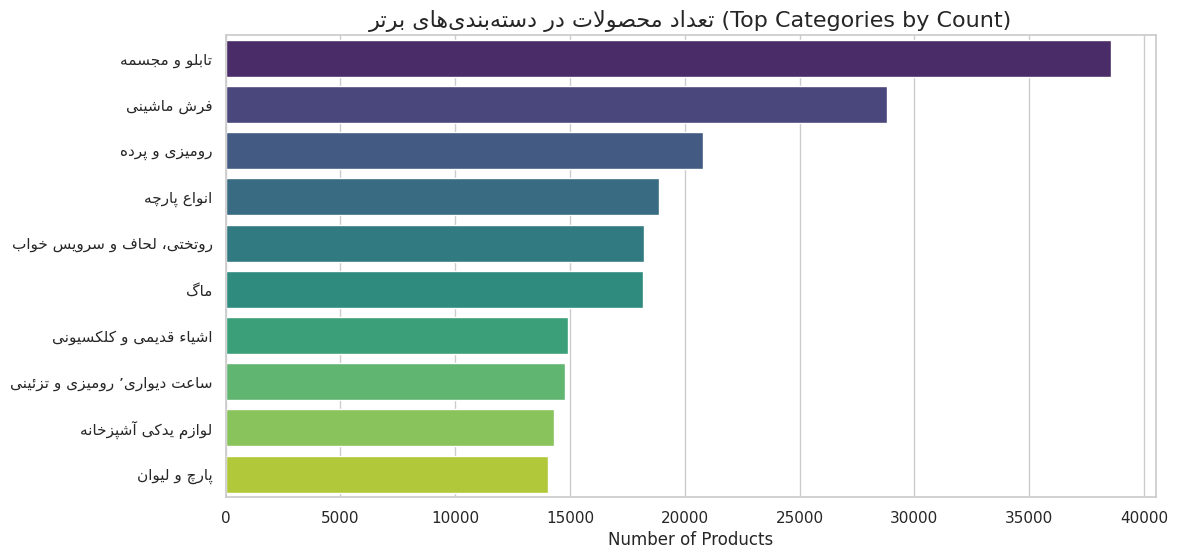

💡 INSIGHT (Price Distribution):
   - The 'Box' shows the normal price range. The dots are outliers.
   - If a category has a very huge box (long vertical line), prices vary wildly (e.g., cheap vs luxury furniture).
   - This helps detect if your data contains dummy prices (like 0 or 1 Rial) that need filtering.


/tmp/ipython-input-526657106.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=subset_price, x='title_fixed', y='mean', palette="mako")


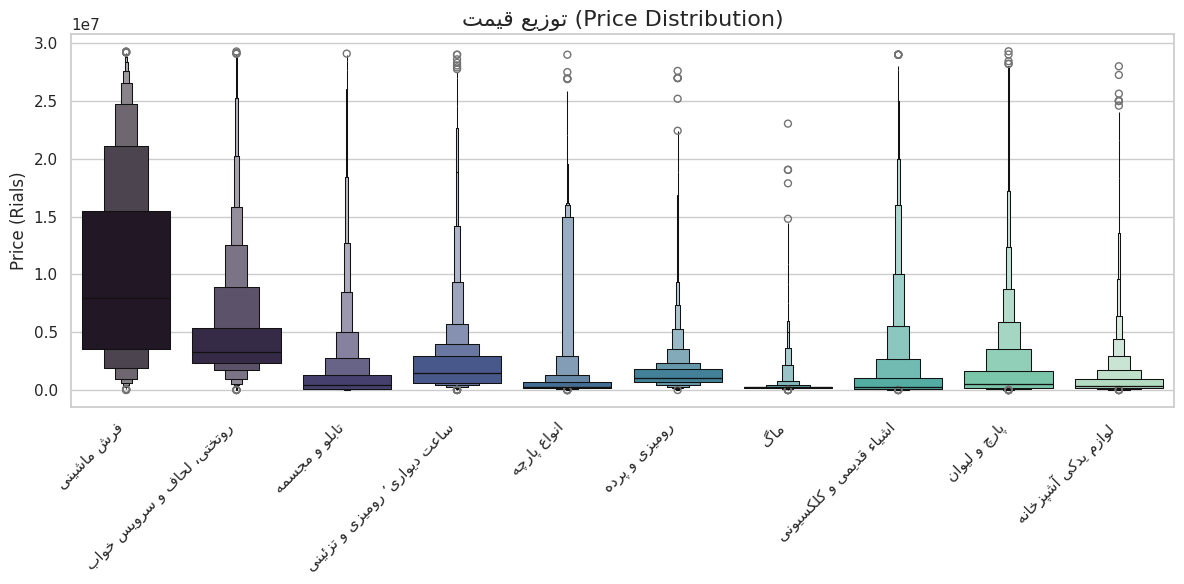

💡 INSIGHT (Query Length):
   - This tells you how users talk to the system.
   - A peak at 0-10 chars means users search keywords (e.g., 'iPhone').
   - A peak at 30+ chars means users ask natural questions (e.g., 'Best phone for photography under 20m').
   - Your RAG retriever strategy depends on this (Keyword search vs. Semantic search).


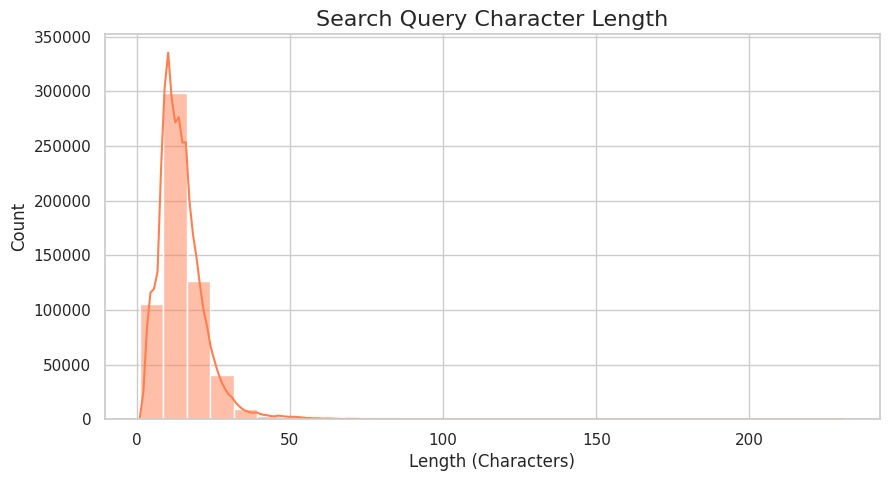

💡 INSIGHT (Interactions):
   - This separates 'Window Shopping' from 'Buying'.
   - Products with High Views but Zero Clicks might have bad images or misleading titles.
   - Products with High Clicks are your 'Gold Data'. We prioritize these for the dataset.


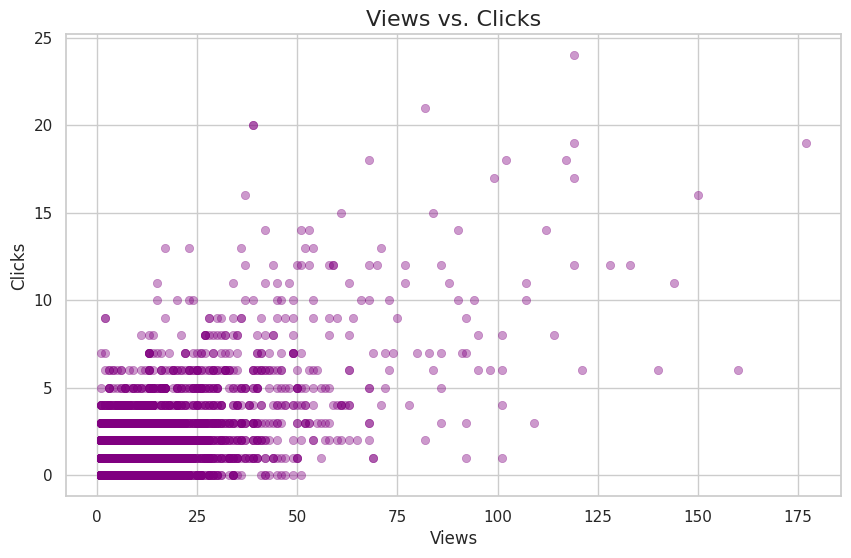

💡 INSIGHT (Top Attributes - 'What is this?'):
   - This chart reads the `extra_features` column (which is a dictionary/JSON) and counts the keys.
   - Example: If 'Weight' (وزن) and 'Dimensions' (ابعاد) are at the top, it means most products have these details.
   - **Use Case:** When building your RAG, these are the fields you should index. You can allow users to filter by 'Color' or 'Warranty' because you know these attributes exist in the data.


/tmp/ipython-input-526657106.py:109: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_keys.values, y=safe_keys, palette="autumn")


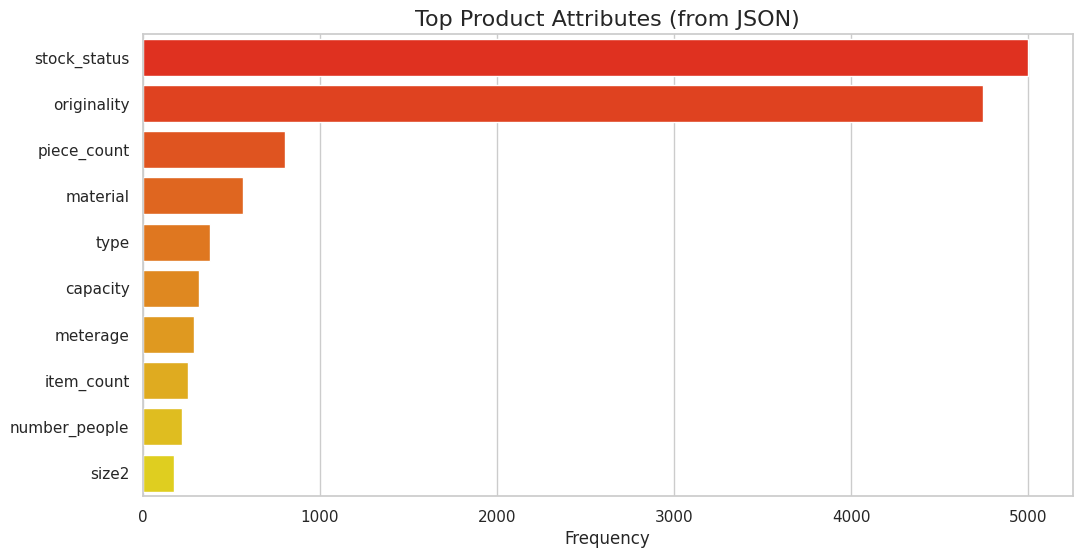

In [18]:
# ==========================================
# 4. DATA ANALYSIS & VISUALIZATION (UPDATED)
# ==========================================
print("\n📊 Generating Enhanced Analysis Plots...")

# --- PLOT 1: Top Categories by Product Count (NEW) ---
print("💡 INSIGHT (Top Categories):")
print("   - This shows which parts of your dataset are 'dense'.")
print("   - If 'Mobile Phones' has the most products, your RAG system will be best at answering phone-related questions.")
print("   - Categories with very few products might need more data collection or should be excluded.")

plt.figure(figsize=(12, 6))
# Count products per category
cat_counts = full_df['title'].value_counts().head(10)
# Fix Persian text
safe_labels = [safe_persian(idx) for idx in cat_counts.index]

sns.barplot(x=cat_counts.values, y=safe_labels, palette="viridis")
plt.title(safe_persian("تعداد محصولات در دسته‌بندی‌های برتر") + " (Top Categories by Count)", fontsize=16)
plt.xlabel("Number of Products")
plt.show()

print("="*50)



# --- PLOT 2: Price Distribution (Boxen Plot) ---
print("💡 INSIGHT (Price Distribution):")
print("   - The 'Box' shows the normal price range. The dots are outliers.")
print("   - If a category has a very huge box (long vertical line), prices vary wildly (e.g., cheap vs luxury furniture).")
print("   - This helps detect if your data contains dummy prices (like 0 or 1 Rial) that need filtering.")


plt.figure(figsize=(12, 6))
top_cats_list = full_df['title'].value_counts().head(10).index
subset_price = full_df[full_df['title'].isin(top_cats_list)].copy()
subset_price = subset_price[subset_price['mean'] < subset_price['mean'].quantile(0.99)] # Remove crazy outliers
subset_price['title_fixed'] = subset_price['title'].apply(safe_persian)

sns.boxenplot(data=subset_price, x='title_fixed', y='mean', palette="mako")
plt.title(safe_persian("توزیع قیمت") + " (Price Distribution)", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Price (Rials)")
plt.xlabel("")
plt.tight_layout()
plt.show()
print("="*50)

# --- PLOT 3: Search Query Length ---
print("💡 INSIGHT (Query Length):")
print("   - This tells you how users talk to the system.")
print("   - A peak at 0-10 chars means users search keywords (e.g., 'iPhone').")
print("   - A peak at 30+ chars means users ask natural questions (e.g., 'Best phone for photography under 20m').")
print("   - Your RAG retriever strategy depends on this (Keyword search vs. Semantic search).")


plt.figure(figsize=(10, 5))
df_searches['q_len'] = df_searches['query'].astype(str).str.len()
sns.histplot(df_searches['q_len'], bins=30, kde=True, color='coral')
plt.title("Search Query Character Length", fontsize=16)
plt.xlabel("Length (Characters)")
plt.show()
print("="*50)


# --- PLOT 4: Interaction Map (Views vs Clicks) ---
print("💡 INSIGHT (Interactions):")
print("   - This separates 'Window Shopping' from 'Buying'.")
print("   - Products with High Views but Zero Clicks might have bad images or misleading titles.")
print("   - Products with High Clicks are your 'Gold Data'. We prioritize these for the dataset.")

plt.figure(figsize=(10, 6))
# (Same logic as before)
view_counts = df_views['base_product_rk'].value_counts()
click_counts = df_clicks.merge(df_views[['id', 'base_product_rk']],
                               left_on='base_view_id', right_on='id', how='left')['base_product_rk'].value_counts()
interaction_df = pd.DataFrame({'views': view_counts, 'clicks': click_counts}).fillna(0)
plot_data = interaction_df[(interaction_df['views'] > 0) & (interaction_df['views'] < 500)]

sns.scatterplot(data=plot_data, x='views', y='clicks', alpha=0.4, color='purple', edgecolor=None)
plt.title("Views vs. Clicks", fontsize=16)
plt.xlabel("Views")
plt.ylabel("Clicks")
plt.show()
print("="*50)



# --- PLOT 5: Top Product Attributes (JSON Analysis) ---
print("💡 INSIGHT (Top Attributes - 'What is this?'):")
print("   - This chart reads the `extra_features` column (which is a dictionary/JSON) and counts the keys.")
print("   - Example: If 'Weight' (وزن) and 'Dimensions' (ابعاد) are at the top, it means most products have these details.")
print("   - **Use Case:** When building your RAG, these are the fields you should index. You can allow users to filter by 'Color' or 'Warranty' because you know these attributes exist in the data.")


plt.figure(figsize=(12, 6))
def get_json_keys(x):
    try:
        if x is None: return []
        if isinstance(x, str): return list(json.loads(x.replace("'", '"')).keys())
        return list(x.keys())
    except: return []

# Sampling 5000 rows to find common keys
all_keys = full_df['extra_features'].sample(min(5000, len(full_df))).dropna().apply(get_json_keys).explode()
top_keys = all_keys.value_counts().head(10)
safe_keys = [safe_persian(k) for k in top_keys.index]

sns.barplot(x=top_keys.values, y=safe_keys, palette="autumn")
plt.title("Top Product Attributes (from JSON)", fontsize=16)
plt.xlabel("Frequency")
plt.show()
print("="*50)


# Step 5: EXTRACTING STRATIFIED TOP 10K


🧹 Extracting 'Good Data' Subset...

📊 DATA CLEANING & IMAGE AUDIT:
1. Initial Total Products: 1,022,298
2. Image Validity Audit:
   - Found 3,341 records with invalid images (NaN or Empty).
   - Action: Removing these 3,341 rows to ensure visual eligibility.
--------------------------------------------------
TOTAL REMOVED:             3,341
✅ REMAINING GOOD DATA:     1,018,957

⚖️ Performing Stratified Sampling...
   - Global Sampling Rate: 0.9814%


/tmp/ipython-input-3669774734.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = good_data.groupby('category_name', group_keys=False).apply(get_top_percent)


✅ Selected 10000 images.
   - Metadata saved to: torob_top_10k_images.csv

🔍 SUBSET ANALYSIS (TOP 10K):
   - Diversity: 600 Categories
   - Avg Views: 7
   - Avg Clicks: 1.2


<Figure size 1400x600 with 0 Axes>

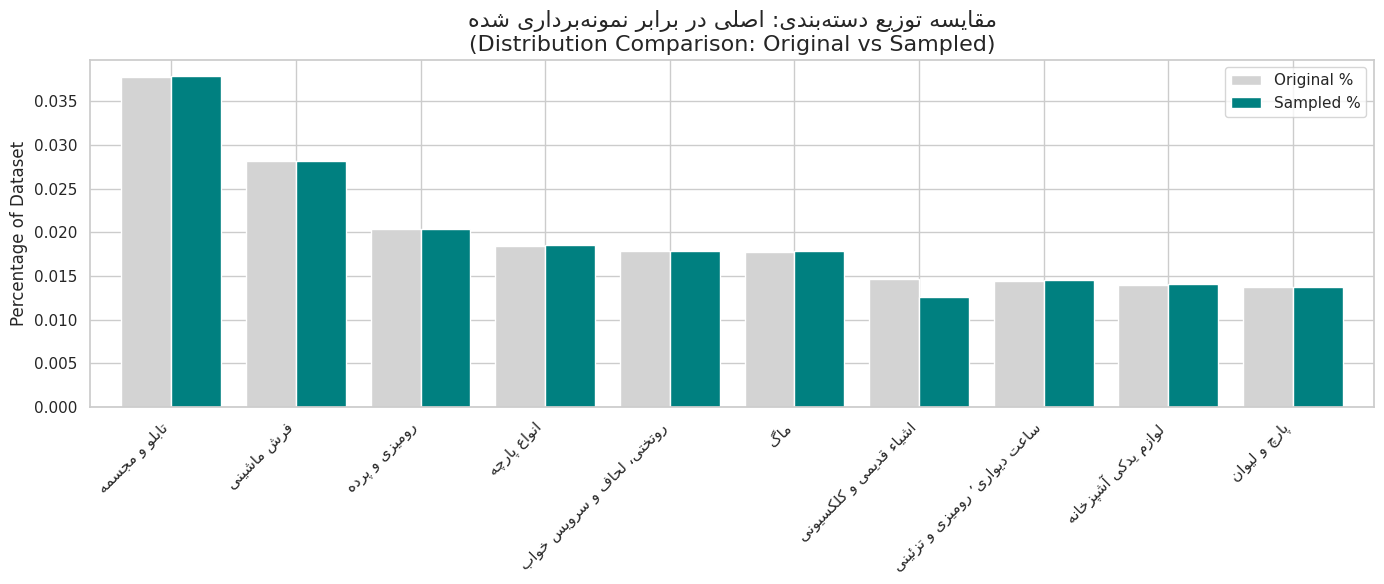

description: The gray bars (Original) and teal bars (Sampled) should be almost the same height. This proves your dataset is a perfect 'mini-twin' of the real world.


In [19]:
print("\n🧹 Extracting 'Good Data' Subset...")

# --- A. CALCULATE RELEVANCE SCORE ---
if 'relevance_score' not in full_df.columns:
    if 'views' not in full_df.columns:
        view_counts = df_views['base_product_rk'].value_counts()
        click_counts = df_clicks.merge(df_views[['id', 'base_product_rk']],
                                       left_on='base_view_id', right_on='id', how='left')['base_product_rk'].value_counts()
        full_df['views'] = full_df['random_key'].map(view_counts).fillna(0)
        full_df['clicks'] = full_df['random_key'].map(click_counts).fillna(0)

    # Simple weighted score: Clicks are worth 10x Views
    full_df['relevance_score'] = full_df['views'] + (full_df['clicks'] * 10)

# --- B. EXPLICIT IMAGE AUDIT & CLEANING ---
print("\n📊 DATA CLEANING & IMAGE AUDIT:")
print("="*50)
initial_count = len(full_df)
print(f"1. Initial Total Products: {initial_count:,}")

# 1. Audit Image Missingness (Technical NaN + Logical Empty)
# We define "Logical Null" as empty string or string shorter than 36 chars (e.g., "https://image.torob.com/base/images/")
technical_nulls = full_df['image_url'].isnull()
logical_nulls = full_df['image_url'].astype(str).str.len() < len("https://image.torob.com/base/images/")
invalid_image_mask = technical_nulls | logical_nulls

invalid_img_count = invalid_image_mask.sum()
print(f"2. Image Validity Audit:")
print(f"   - Found {invalid_img_count:,} records with invalid images (NaN or Empty).")
print(f"   - Action: Removing these {invalid_img_count:,} rows to ensure visual eligibility.")

# 2. Filter the Data
# Keep rows that are NOT invalid images AND have a Persian Name
good_data = full_df[
    (~invalid_image_mask) &
    (full_df['persian_name'].notnull())
].copy()

# Rename title to category_name for consistency
if 'title' in good_data.columns:
    good_data = good_data.rename(columns={'title': 'category_name'})

dropped_total = initial_count - len(good_data)
print("-" * 50)
print(f"TOTAL REMOVED:             {dropped_total:,}")
print(f"✅ REMAINING GOOD DATA:     {len(good_data):,}")
print("="*50)

# --- C. STRATIFIED SAMPLING ---
print("\n⚖️ Performing Stratified Sampling...")
TARGET_SIZE = 10000

# 1. Calculate Global Sampling Rate
global_sampling_rate = TARGET_SIZE / len(good_data)
print(f"   - Global Sampling Rate: {global_sampling_rate:.4%}")

# 2. Define Sampling Logic (Top N items per category by Score)
def get_top_percent(group):
    n_samples = int(np.ceil(len(group) * global_sampling_rate))
    return group.nlargest(n_samples, 'relevance_score')

# 3. Apply Grouping & Sampling
stratified_sample = good_data.groupby('category_name', group_keys=False).apply(get_top_percent)

# 4. Exact Trimming (to exactly 10,000)
top_10k_images = stratified_sample.sort_values('relevance_score', ascending=False).head(TARGET_SIZE).copy()

# Save the metadata CSV
file_name_10k = "torob_top_10k_images.csv"
top_10k_images[['random_key', 'image_url', 'persian_name', 'category_name', 'relevance_score']].to_csv(file_name_10k, index=False)

print(f"✅ Selected {len(top_10k_images)} images.")
print(f"   - Metadata saved to: {file_name_10k}")

# --- F. ANALYSIS OF THE 10K SUBSET ---
print("\n🔍 SUBSET ANALYSIS (TOP 10K):")
print(f"   - Diversity: {top_10k_images['category_name'].nunique()} Categories")
print(f"   - Avg Views: {top_10k_images['views'].mean():.0f}")
print(f"   - Avg Clicks: {top_10k_images['clicks'].mean():.1f}")

# --- VISUALIZATION: COMPARE DISTRIBUTIONS ---
# We plot Original vs Sampled to prove they match
plt.figure(figsize=(14, 6))

# Get top 10 categories from original data
top_cats_original = good_data['category_name'].value_counts(normalize=True).head(10)
# Get same categories from our sample
top_cats_sample = top_10k_images['category_name'].value_counts(normalize=True).loc[top_cats_original.index]

# Create DataFrame for plotting
comp_df = pd.DataFrame({
    'Original %': top_cats_original,
    'Sampled %': top_cats_sample
})

# Fix Persian Labels
safe_labels = [safe_persian(l) for l in comp_df.index]
comp_df.index = safe_labels

comp_df.plot(kind='bar', figsize=(14, 6), color=['lightgray', 'teal'], width=0.8)
plt.title(safe_persian("مقایسه توزیع دسته‌بندی: اصلی در برابر نمونه‌برداری شده") + "\n(Distribution Comparison: Original vs Sampled)", fontsize=16)
plt.ylabel("Percentage of Dataset")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

print("description: The gray bars (Original) and teal bars (Sampled) should be almost the same height. This proves your dataset is a perfect 'mini-twin' of the real world.")

# Step 6: High-Speed Download & Upload

In [20]:
# # --- CONFIG ---
# OUTPUT_DIR = "balanced_images"
# CSV_FILE = "torob_top_10k_images.csv"
# IMAGES_DIR = os.path.join(OUTPUT_DIR, "images")
# os.makedirs(IMAGES_DIR, exist_ok=True)
# MAX_WORKERS = 16

# # 1. READ CSV
# df_to_download = pd.read_csv(CSV_FILE)
# print(f"⬇️  Downloading {len(df_to_download)} images with {MAX_WORKERS} threads...")

# # 2. DOWNLOADER FUNCTION
# def download_single_image(row):
#     img_url = row['image_url']
#     random_key = row['random_key']
#     file_name = f"{random_key}.jpg"
#     save_path = os.path.join(IMAGES_DIR, file_name)

#     if os.path.exists(save_path):
#         record = row.to_dict()
#         record['image_path'] = f"images/{file_name}"
#         return record

#     try:
#         response = requests.get(img_url, timeout=5)
#         if response.status_code == 200:
#             image = Image.open(BytesIO(response.content)).convert('RGB')
#             image.save(save_path, "JPEG", quality=85)
#             record = row.to_dict()
#             record['image_path'] = f"images/{file_name}"
#             return record
#     except:
#         pass
#     return None

# # 3. EXECUTE
# valid_records = []
# rows_to_process = [row for _, row in df_to_download.iterrows()]

# with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
#     results = list(tqdm(executor.map(download_single_image, rows_to_process), total=len(rows_to_process)))

# valid_records = [r for r in results if r is not None]

# # 4. SAVE PARQUET
# final_df = pd.DataFrame(valid_records)
# final_df.to_parquet(os.path.join(OUTPUT_DIR, "data.parquet"), index=False)
# print(f"✅ Downloaded {len(final_df)} images.")

# # 5. UPLOAD
# print("\n🚀 UPLOAD TO HUGGING FACE")
# if input("Upload now? (y/n): ").lower() == 'y':
#     try:
#         login(add_to_git_credential=True)
#         api = HfApi()

#         # Auto-detect username
#         try: username = api.whoami()['name']
#         except: username = input("Enter HF Username: ")

#         repo_name = input(f"Repo Name (default: {username}/torob-clean-10k): ") or f"{username}/torob-clean-10k"
#         if "/" not in repo_name: repo_name = f"{username}/{repo_name}"

#         print(f"📦 Creating {repo_name}...")
#         api.create_repo(repo_id=repo_name, repo_type="dataset", exist_ok=True)

#         print("📤 Uploading files...")
#         api.upload_folder(folder_path=OUTPUT_DIR, repo_id=repo_name, repo_type="dataset")

#         # Create README
#         readme = f"""
# ---
# dataset_info:
#   features:
#   - name: image_path
#     dtype: string
#   - name: persian_name
#     dtype: string
#   - name: relevance_score
#     dtype: float64
# task_categories:
# - retrieval
# tags:
# - torob
# - clean-data
# size_categories:
# - 10k<n<100k
# ---
# # Torob Clean Stratified Dataset (10k)

# **Total Images:** {len(final_df)}
# **Cleaning Applied:** Duplicates removed, Text Normalized (Persian), Price Outliers removed.
# **Sampling:** Stratified by category (Score-based).
# """
#         with open("README.md", "w") as f: f.write(readme)
#         api.upload_file(path_or_fileobj="README.md", path_in_repo="README.md", repo_id=repo_name, repo_type="dataset")

#         print(f"✅ Success: https://huggingface.co/datasets/{repo_name}")
#     except Exception as e:
#         print(f"❌ Error: {e}")